# Análisis de colinealidad

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
DATA_DIR = Path("datos")
TICKERS = ["NVDA", "MSFT", "GOOGL"]
NON_FEATURES = ["Date", "Target_Retorno_1d", "Target_Direccion"]

datasets = {t: pd.read_csv(DATA_DIR / f"{t}_dataset.csv", parse_dates=["Date"]) for t in TICKERS}
feature_cols = [c for c in datasets[TICKERS[0]].columns if c not in NON_FEATURES]
print(f"{len(feature_cols)} features:", feature_cols)

21 features: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'WMA_20', 'RSI_14', 'MACD', 'MACD_signal', 'BB_upper', 'BB_mid', 'BB_lower', 'Momentum_10', 'Stoch_K', 'Stoch_D', 'WilliamsR_14', 'SP500_ret', 'NASDAQ_ret', 'Gold_ret']


## Correlación

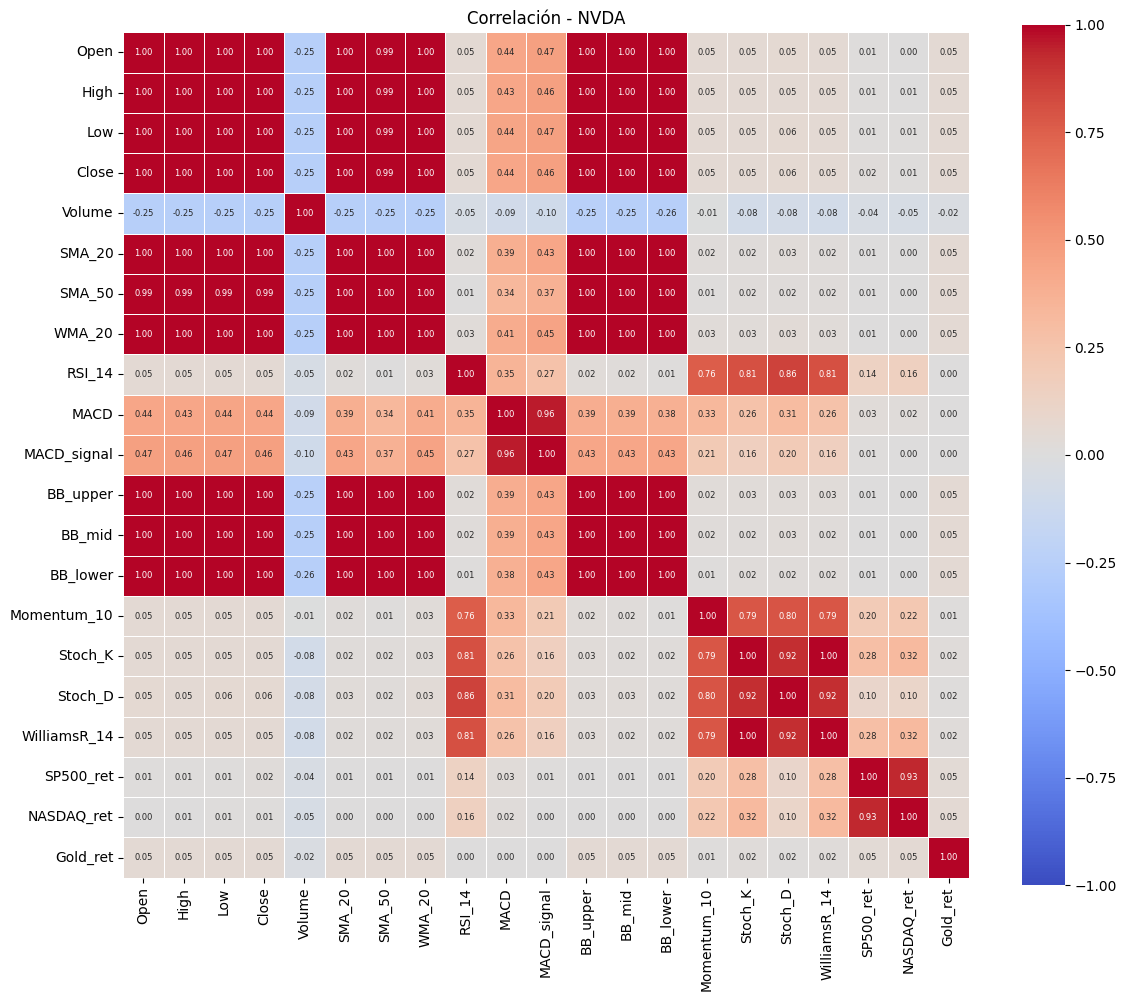

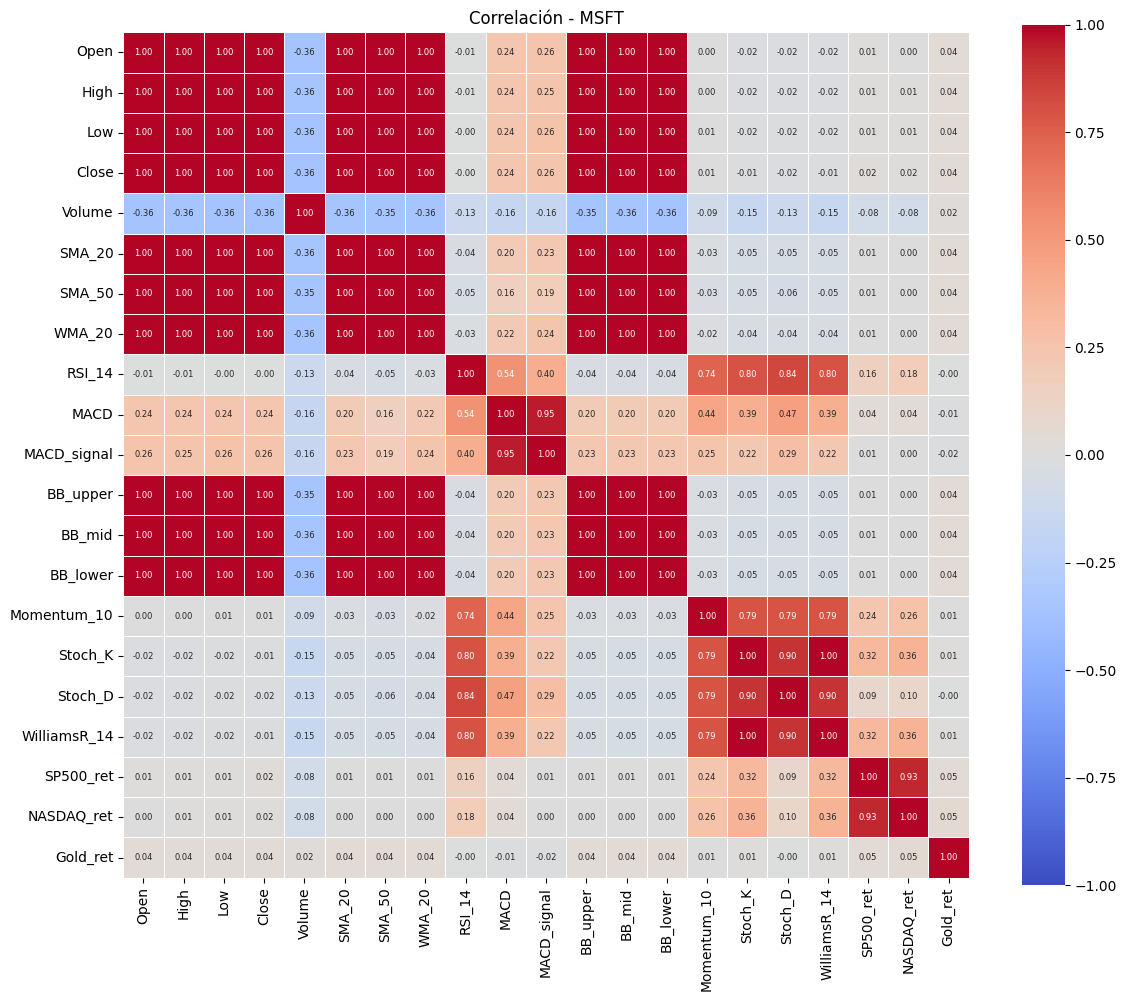

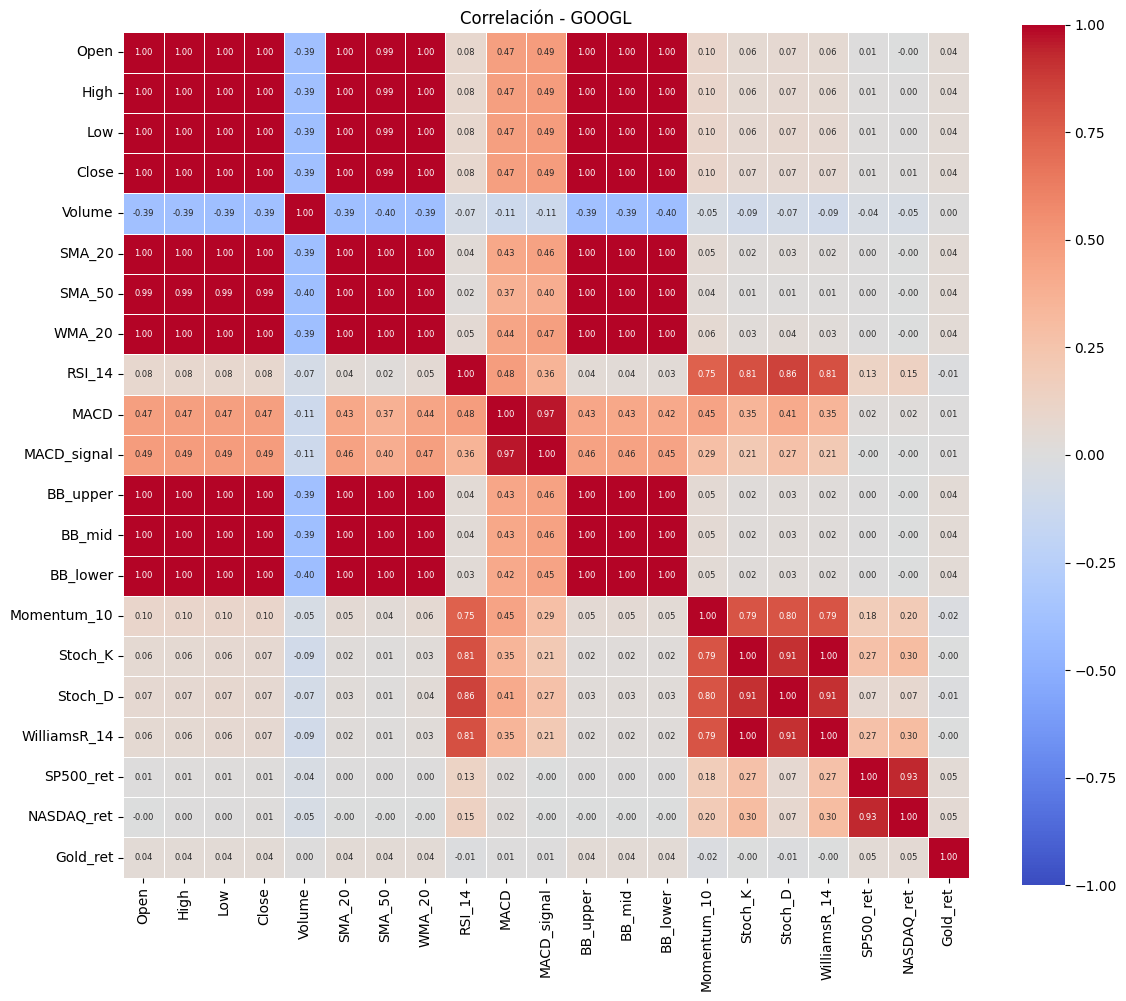

In [3]:
def matriz_corr(df, cols):
    return df[cols].apply(pd.to_numeric, errors="coerce").dropna().corr()

for t in TICKERS:
    plt.figure(figsize=(12, 10))
    sns.heatmap(matriz_corr(datasets[t], feature_cols), cmap="coolwarm", vmin=-1, vmax=1,
                center=0, square=True, linewidths=0.5, annot=True, fmt=".2f", annot_kws={"size": 6})
    plt.title(f"Correlación - {t}")
    plt.tight_layout()
    plt.show()

## Pares |r| >= 0.9

In [4]:
UMBRAL = 0.90

def pares_correlacionados(corr, umbral=UMBRAL):
    cols = corr.columns
    pares = [(cols[i], cols[j], round(corr.iloc[i, j], 4))
             for i in range(len(cols)) for j in range(i + 1, len(cols))
             if abs(corr.iloc[i, j]) >= umbral]
    return (pd.DataFrame(pares, columns=["feature_1", "feature_2", "r"])
            .sort_values("r", key=lambda s: s.abs(), ascending=False)
            .reset_index(drop=True))

for t in TICKERS:
    pares = pares_correlacionados(matriz_corr(datasets[t], feature_cols))
    print(f"\n{t}: {len(pares)} pares con |r| >= {UMBRAL}")
    display(pares)


NVDA: 50 pares con |r| >= 0.9


,feature_1,feature_2,r
0,Stoch_K,WilliamsR_14,1.0000
1,SMA_20,BB_mid,1.0000
2,Open,High,0.9999
3,Low,Close,0.9999
4,Open,Low,0.9998
5,High,Low,0.9998
6,SMA_20,WMA_20,0.9998
7,WMA_20,BB_mid,0.9998
8,High,Close,0.9998
9,Open,Close,0.9996



MSFT: 50 pares con |r| >= 0.9


,feature_1,feature_2,r
0,Stoch_K,WilliamsR_14,1.0000
1,SMA_20,BB_mid,1.0000
2,High,Low,0.9999
3,High,Close,0.9999
4,Low,Close,0.9999
5,Open,Low,0.9999
6,SMA_20,WMA_20,0.9999
7,WMA_20,BB_mid,0.9999
8,Open,High,0.9999
9,Open,Close,0.9998



GOOGL: 50 pares con |r| >= 0.9


,feature_1,feature_2,r
0,Stoch_K,WilliamsR_14,1.0000
1,SMA_20,BB_mid,1.0000
2,High,Low,0.9999
3,High,Close,0.9999
4,Low,Close,0.9999
5,Open,Low,0.9999
6,Open,High,0.9999
7,WMA_20,BB_mid,0.9998
8,SMA_20,WMA_20,0.9998
9,Open,Close,0.9997


## Duplicados exactos

In [5]:
for t in TICKERS:
    df = datasets[t]
    d1 = (df["BB_mid"] - df["SMA_20"]).abs().max()
    d2 = (df["WilliamsR_14"] - (df["Stoch_K"] - 100)).abs().max()
    print(f"{t}: max|BB_mid-SMA_20|={d1:.2e} | max|WilliamsR_14-(Stoch_K-100)|={d2:.2e}")

NVDA: max|BB_mid-SMA_20|=0.00e+00 | max|WilliamsR_14-(Stoch_K-100)|=2.98e-14
MSFT: max|BB_mid-SMA_20|=0.00e+00 | max|WilliamsR_14-(Stoch_K-100)|=3.11e-14
GOOGL: max|BB_mid-SMA_20|=0.00e+00 | max|WilliamsR_14-(Stoch_K-100)|=3.02e-14


## VIF (set completo)

In [6]:
def calcular_vif(df, cols):
    X = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
    X = X.loc[:, X.std() > 0]
    Xc = add_constant(X)
    vif = pd.DataFrame({"feature": Xc.columns,
                        "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]})
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

for t in TICKERS:
    print(f"\nVIF - {t}")
    display(calcular_vif(datasets[t], feature_cols))


VIF - NVDA


,feature,VIF
0,Stoch_K,inf
1,BB_lower,inf
2,BB_upper,inf
3,BB_mid,inf
4,SMA_20,inf
5,WilliamsR_14,inf
6,WMA_20,5.960340e+04
7,SMA_50,1.616529e+04
8,High,1.129170e+04
9,Close,1.022815e+04



VIF - MSFT


,feature,VIF
0,Stoch_K,inf
1,BB_lower,inf
2,BB_upper,inf
3,BB_mid,inf
4,SMA_20,inf
5,WilliamsR_14,inf
6,WMA_20,1.303302e+05
7,SMA_50,2.901846e+04
8,Close,2.484946e+04
9,Low,2.062123e+04



VIF - GOOGL


,feature,VIF
0,Stoch_K,inf
1,BB_lower,inf
2,BB_upper,inf
3,BB_mid,inf
4,SMA_20,inf
5,WilliamsR_14,inf
6,WMA_20,6.910014e+04
7,SMA_50,1.597716e+04
8,Close,1.434788e+04
9,Low,1.237492e+04


## Selección iterativa por VIF
Se elimina la variable con mayor VIF y se recalcula, hasta que todas tengan VIF < 10.

In [7]:
def vif_iterativo(df, cols, umbral=10.0):
    cols = list(cols)
    removidas = []
    while len(cols) > 1:
        v = calcular_vif(df, cols)            # ordenado de mayor a menor
        peor, val = v.iloc[0]["feature"], v.iloc[0]["VIF"]
        if val < umbral:
            break
        removidas.append((peor, round(val, 1)))
        cols.remove(peor)
    return cols, removidas

sets_finales = {}
for t in TICKERS:
    final, removidas = vif_iterativo(datasets[t], feature_cols)
    sets_finales[t] = final
    print(f"\n=== {t} ===")
    print("  Eliminadas (en orden):", [r[0] for r in removidas])
    print("  Set final:", final)
    display(calcular_vif(datasets[t], final))


=== NVDA ===
  Eliminadas (en orden): ['Stoch_K', 'BB_mid', 'BB_lower', 'WMA_20', 'SMA_20', 'High', 'Low', 'Open', 'SMA_50', 'Close', 'MACD', 'Stoch_D']
  Set final: ['Volume', 'RSI_14', 'MACD_signal', 'BB_upper', 'Momentum_10', 'WilliamsR_14', 'SP500_ret', 'NASDAQ_ret', 'Gold_ret']


,feature,VIF
0,NASDAQ_ret,8.001402
1,SP500_ret,7.768273
2,WilliamsR_14,4.085403
3,RSI_14,3.585555
4,Momentum_10,3.049707
5,MACD_signal,1.362508
6,BB_upper,1.322194
7,Volume,1.086065
8,Gold_ret,1.005286



=== MSFT ===
  Eliminadas (en orden): ['Stoch_K', 'BB_mid', 'BB_lower', 'WMA_20', 'SMA_20', 'Close', 'Open', 'High', 'SMA_50', 'Low', 'MACD', 'Stoch_D']
  Set final: ['Volume', 'RSI_14', 'MACD_signal', 'BB_upper', 'Momentum_10', 'WilliamsR_14', 'SP500_ret', 'NASDAQ_ret', 'Gold_ret']


,feature,VIF
0,NASDAQ_ret,8.045651
1,SP500_ret,7.779444
2,WilliamsR_14,4.193817
3,RSI_14,3.537288
4,Momentum_10,2.929635
5,MACD_signal,1.314941
6,BB_upper,1.228711
7,Volume,1.190532
8,Gold_ret,1.006586



=== GOOGL ===
  Eliminadas (en orden): ['Stoch_K', 'BB_mid', 'BB_lower', 'WMA_20', 'Close', 'SMA_20', 'Open', 'High', 'SMA_50', 'Low', 'MACD', 'Stoch_D']
  Set final: ['Volume', 'RSI_14', 'MACD_signal', 'BB_upper', 'Momentum_10', 'WilliamsR_14', 'SP500_ret', 'NASDAQ_ret', 'Gold_ret']


,feature,VIF
0,NASDAQ_ret,7.984645
1,SP500_ret,7.769496
2,WilliamsR_14,4.198770
3,RSI_14,3.590626
4,Momentum_10,2.978566
5,MACD_signal,1.545724
6,BB_upper,1.531441
7,Volume,1.199485
8,Gold_ret,1.005787


In [8]:
comun = sorted(set.intersection(*[set(v) for v in sets_finales.values()]))
print("¿Los 3 sets coinciden?", len({frozenset(v) for v in sets_finales.values()}) == 1)
print(f"Intersección común ({len(comun)}):", comun)

¿Los 3 sets coinciden? True
Intersección común (9): ['BB_upper', 'Gold_ret', 'MACD_signal', 'Momentum_10', 'NASDAQ_ret', 'RSI_14', 'SP500_ret', 'Volume', 'WilliamsR_14']


## Tratamiento de BB_upper con la diferencia lag-1 y recálculo de VIF

`BB_upper` es la única variable del set común (9) que la ADF marca **no estacionaria** (es un nivel de
precio; el VIF la dejó pasar porque VIF ≠ estacionariedad). Se reemplaza por su **diferencia de orden 1**
(`BB_upper.diff()`), que sí es estacionaria, y se recalcula el VIF del set para confirmar que la
transformación no introduce colinealidad nueva.

In [9]:
# Reemplaza BB_upper por su diferencia lag-1 (estacionaria) y recalcula el VIF del set comun
set_lag1 = ["BB_upper_diff" if c == "BB_upper" else c for c in comun]

datasets_lag1 = {}
for t in TICKERS:
    df = datasets[t].copy()
    df["BB_upper_diff"] = df["BB_upper"].diff()   # diferencia de orden 1
    datasets_lag1[t] = df

print("Set evaluado:", set_lag1)
for t in TICKERS:
    print(f"\nVIF (BB_upper -> diferencia lag-1) - {t}")
    display(calcular_vif(datasets_lag1[t], set_lag1))

Set evaluado: ['BB_upper_diff', 'Gold_ret', 'MACD_signal', 'Momentum_10', 'NASDAQ_ret', 'RSI_14', 'SP500_ret', 'Volume', 'WilliamsR_14']

VIF (BB_upper -> diferencia lag-1) - NVDA


,feature,VIF
0,NASDAQ_ret,8.005126
1,SP500_ret,7.775876
2,WilliamsR_14,4.080204
3,RSI_14,3.553756
4,Momentum_10,3.110088
5,BB_upper_diff,1.318947
6,MACD_signal,1.299946
7,Volume,1.033756
8,Gold_ret,1.002889



VIF (BB_upper -> diferencia lag-1) - MSFT


,feature,VIF
0,NASDAQ_ret,8.072665
1,SP500_ret,7.806661
2,WilliamsR_14,4.185957
3,RSI_14,3.520662
4,Momentum_10,3.008663
5,MACD_signal,1.396762
6,BB_upper_diff,1.365284
7,Volume,1.055921
8,Gold_ret,1.003040



VIF (BB_upper -> diferencia lag-1) - GOOGL


,feature,VIF
0,NASDAQ_ret,7.999510
1,SP500_ret,7.787069
2,WilliamsR_14,4.202155
3,RSI_14,3.552171
4,Momentum_10,3.101820
5,BB_upper_diff,1.429136
6,MACD_signal,1.362283
7,Volume,1.029021
8,Gold_ret,1.003701
